In [1]:
import pandas as pd
import numpy as np

from gpcam import GPOptimizer

import matplotlib.pyplot as plt
import plotly.graph_objects as go

import mrcfile

from scipy.spatial.distance import cdist

# Loading the Data

In [2]:
rho = np.zeros((50, 128, 128, 128), dtype=np.float32) # 100, 128,128,128
for i in range(50): # 100
    fname = f'128_org/{i:03d}.mrc'  # formats as 000, 001, 002, etc.
    with mrcfile.open(fname, permissive=True) as mrc:
        rho[i] = mrc.data

angles = np.linspace(0.0, 180.0, 50, endpoint=True) # 360, 100, endpoint=False

In [3]:
rho.shape

(50, 128, 128, 128)

In [4]:
import plotly.graph_objects as go

# Get the 3D volume
volume = rho[0]

# Create coordinate grids
x, y, z = np.meshgrid(range(128), range(128), range(128), indexing='ij')

# Flatten everything
x_flat = x.flatten()
y_flat = y.flatten()
z_flat = z.flatten()
values_flat = volume.flatten()

# Filter by threshold to avoid plotting all 2M+ points
threshold = volume.max() * 0.5  # adjust as needed
mask = values_flat > threshold

# Create 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=x_flat[mask],
    y=y_flat[mask],
    z=z_flat[mask],
    mode='markers',
    marker=dict(
        size=2,
        color=values_flat[mask],
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title="Intensity")
    )
)])

fig.update_layout(
    title='3D Scatter Plot of rho[0]',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    ),
    width=900,
    height=700
)

fig.show()

# Compute Distances between Volumes

In [5]:
# import os
# import ot
# from scipy.spatial.distance import cdist as scipy_cdist

# # ===== ADAPTED DISTANCE FUNCTIONS FOR 3D VOLUMES =====

# def sliced_wasserstein_3d(p, q, n_projections=50):
#     """
#     Sliced Wasserstein for 3D volume
#     p, q: flattened (128*128*128,) distributions
#     """
#     # Create 3D position grid
#     positions = np.array([[i, j, k] 
#                          for i in range(128) 
#                          for j in range(128) 
#                          for k in range(128)])
    
#     sw_dist = ot.sliced_wasserstein_distance(
#         positions, positions,
#         p, q,
#         n_projections=n_projections,
#         seed=42
#     )
#     return sw_dist

# def gromov_wasserstein_3d(p, q):
#     """
#     Gromov-Wasserstein for 3D volumes
#     WARNING: This will be VERY slow for 128^3 points
#     Consider downsampling first!
#     """
#     p_features = p.reshape(-1, 1)
#     q_features = q.reshape(-1, 1)
    
#     C1 = scipy_cdist(p_features, p_features, metric='euclidean')
#     C2 = scipy_cdist(q_features, q_features, metric='euclidean')
    
#     p_weights = p / p.sum()
#     q_weights = q / q.sum()
    
#     return ot.gromov.gromov_wasserstein2(
#         C1, C2, p_weights, q_weights, 
#         loss_fun='square_loss', log=False
#     )

# def JS_divergence_3d(p, q, eps=1e-10):
#     """JS divergence - works directly on flattened volumes"""
#     p_safe = np.clip(p, eps, None)
#     q_safe = np.clip(q, eps, None)
    
#     # Normalize to make them probability distributions
#     p_norm = p_safe / p_safe.sum()
#     q_norm = q_safe / q_safe.sum()
    
#     M = 0.5 * (p_norm + q_norm)
#     kl_pm = np.sum(p_norm * np.log(p_norm / M))
#     kl_qm = np.sum(q_norm * np.log(q_norm / M))
#     js = 0.5 * (kl_pm + kl_qm)
#     return np.maximum(js, 0.0)

# def compute_distance_matrix(X, distance_func, name=""):
#     """
#     X: shape (100, 128, 128, 128) - your rho array
#     """
#     n = X.shape[0]
#     D_matrix = np.zeros((n, n))
    
#     print(f"Computing {name} distance matrix ({n}x{n})...")
#     for i in range(n):
#         print(f"  Row {i}/{n}...")
#         for j in range(i, n):
#             # Flatten the 3D volumes
#             p = X[i].flatten()
#             q = X[j].flatten()
            
#             # Normalize to probability distributions
#             p = p / p.sum()
#             q = q / q.sum()
            
#             dist = distance_func(p, q)
#             D_matrix[i, j] = dist
#             D_matrix[j, i] = dist
    
#     return D_matrix

# # def compute_distance_matrix(X, distance_func, name=""):
# #     """
# #     X: shape (100, 128, 128, 128) - your rho array
# #     """
# #     n = X.shape[0]
# #     D_matrix = np.zeros((n, n))
    
# #     total_computations = n * (n + 1) // 2  # Upper triangle + diagonal
# #     count = 0
    
# #     print(f"Computing {name} distance matrix ({n}x{n})...")
# #     print(f"Total computations needed: {total_computations}")
    
# #     for i in range(n):
# #         for j in range(i, n):
# #             count += 1
            
# #             # Flatten the 3D volumes
# #             p = X[i].flatten()
# #             q = X[j].flatten()
            
# #             # Normalize to probability distributions
# #             p = p / p.sum()
# #             q = q / q.sum()
            
# #             dist = distance_func(p, q)
# #             D_matrix[i, j] = dist
# #             D_matrix[j, i] = dist
            
# #             # Print progress for each computation
# #             print(f"  [{count}/{total_computations}] D[{i},{j}] = {dist:.6f}")
    
# #     return D_matrix

# # ===== COMPUTE DISTANCE MATRICES =====

# # Recommended: Start with the fastest metrics
# distance_metrics = {
#     'JS': JS_divergence_3d,
#     # 'sliced_Wass': sliced_wasserstein_3d,
#     # 'GW': gromov_wasserstein_3d,  # WARNING: EXTREMELY slow for 128^3!
# }

# for name, func in distance_metrics.items():
#     print(f"\n{'='*70}")
    
#     filename = f'volumes_distance_{name}.npy'
    
#     # Check if file already exists
#     if os.path.exists(filename):
#         print(f"⏭️  SKIPPING {name}: {filename} already exists")
#         D = np.load(filename)
#         print(f"   Loaded existing file - Shape: {D.shape}")
#         print(f"   Min: {np.min(D):.6f}, Max: {np.max(D):.6f}")
#     else:
#         # Compute the distance matrix
#         D = compute_distance_matrix(rho, func, name=name)
        
#         # Save it
#         np.save(filename, D)
        
#         print(f"✅ Saved: {filename}")
#         print(f"   Shape: {D.shape}")
#         print(f"   Min: {np.min(D):.6f}, Max: {np.max(D):.6f}")

# # Save angles (only if not already saved)
# angles_file = 'angles.npy'
# if os.path.exists(angles_file):
#     print(f"\n⏭️  SKIPPING: {angles_file} already exists")
# else:
#     np.save(angles_file, angles)
#     print(f"\n✅ Saved: {angles_file}")

In [6]:
# Test for PSD
def test_kernel_psd(distance_matrix, kernel_func):
    """Test if kernel matrix is positive semi-definite"""
    import numpy as np
    
    # Compute full kernel matrix
    n = distance_matrix.shape[0]
    K = kernel_func(np.arange(n).reshape(-1, 1), 
                    np.arange(n).reshape(-1, 1), 
                    hps=[1.0, 1.0])  # Test hyperparameters
    
    # Check eigenvalues
    eigenvalues = np.linalg.eigvalsh(K)
    min_eigenvalue = np.min(eigenvalues)
    
    print(f"Minimum eigenvalue: {min_eigenvalue}")
    
    if min_eigenvalue < -1e-10:  # Negative beyond numerical error
        print("❌ NOT positive semi-definite!")
        return False
    elif min_eigenvalue < 0:
        print("⚠️  Slightly negative (numerical error)")
        return True
    else:
        print("✅ Positive semi-definite")
        return True

# Test each distance
for dist_name in ['JS', 'sliced_Wass_OT','Sinkhorn_OT', 'Wasserstein_OT']:
    print(f"\n{dist_name}:")
    distance_full = np.load(f'volumes_distance_{dist_name}.npy')
    test_kernel_psd(distance_full, my_kernel)
    


JS:


NameError: name 'my_kernel' is not defined

In [8]:
from sklearn.model_selection import train_test_split

# ===== LOAD PRECOMPUTED MATRICES =====
print("="*70)
print("Loading precomputed data and distances")
print("="*70)

# Choose which distance metric to use
DISTANCE_METRIC = 'sliced_Wass'  # Options: 'JS', 'sliced_Wass_OT_threshold_1e-3', 'Sinkhorn_OT'

distance_full = np.load(f'volumes_distance_{DISTANCE_METRIC}.npy')
#angles = np.load('angles.npy')

print(f"✅ Loaded {DISTANCE_METRIC} distance matrix: {distance_full.shape}")
print(f"✅ Loaded angles: {angles.shape}")

# ===== SPLIT INTO TRAIN/TEST =====
print("\n" + "="*70)
print("Splitting into train/test")
print("="*70)

# Split indices (0 to 99 for the 100 volumes)
indices = np.arange(len(angles))  # 0 to 99
train_idx_unsorted, test_idx_unsorted = train_test_split(
    indices, 
    test_size=0.7, 
    random_state=742#, 42
)

# Sort indices to preserve original order
train_idx = np.sort(train_idx_unsorted)
test_idx = np.sort(test_idx_unsorted)

print(f"✅ Train indices (sorted): {train_idx[:10]}...")  # Show first 10
print(f"✅ Test indices (sorted): {test_idx[:10]}...")
print(f"✅ Initial train size: {len(train_idx)}, Initial test size: {len(test_idx)}")

# Filter test indices to only keep those within train range
min_train = np.min(train_idx)
max_train = np.max(train_idx)

# Keep only test indices within [min_train, max_train]
mask = (test_idx >= min_train) & (test_idx <= max_train)
test_idx_filtered = test_idx[mask]

print(f"🔍 Train range: [{min_train}, {max_train}]")
print(f"✂️  Removed {len(test_idx) - len(test_idx_filtered)} test points outside train range")
print(f"✅ Filtered test indices: {test_idx_filtered[:10]}...")
print(f"✅ Final test size: {len(test_idx_filtered)}")

# Extract train and test angles using filtered indices
y_train = angles[train_idx]
y_test = angles[test_idx_filtered]

# Use the sorted indices as "features" for GP
X_train = train_idx.reshape(-1, 1)  # Shape: (n_train, 1)
X_test = test_idx_filtered.reshape(-1, 1)    # Shape: (n_test_filtered, 1)


print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print(f"\ny_train sample: {y_train[:5]}")
print(f"y_test sample: {y_test[:5]}")

Loading precomputed data and distances
✅ Loaded sliced_Wass distance matrix: (100, 100)
✅ Loaded angles: (50,)

Splitting into train/test
✅ Train indices (sorted): [ 0  2  6  8 10 16 23 26 27 29]...
✅ Test indices (sorted): [ 1  3  4  5  7  9 11 12 13 14]...
✅ Initial train size: 15, Initial test size: 35
🔍 Train range: [0, 49]
✂️  Removed 0 test points outside train range
✅ Filtered test indices: [ 1  3  4  5  7  9 11 12 13 14]...
✅ Final test size: 35

X_train shape: (15, 1)
X_test shape: (35, 1)
y_train shape: (15,)
y_test shape: (35,)

y_train sample: [ 0.          7.34693878 22.04081633 29.3877551  36.73469388]
y_test sample: [ 3.67346939 11.02040816 14.69387755 18.36734694 25.71428571]


# GP Model

In [9]:
from gpcam import kernels

def my_kernel(x1, x2, hps):
    """
    x1, x2: arrays of indices (either train_idx or test_idx)
    """
    # x1 and x2 ARE the indices - just extract them
    x1_idx = x1.astype(int).flatten()
    x2_idx = x2.astype(int).flatten()
    
    # Get distances from full precomputed matrix
    my_distance = distance_full[np.ix_(x1_idx, x2_idx)]
    
    # Apply Matern kernel
    k = hps[0] * kernels.matern_kernel_diff1(my_distance, hps[1])
    
    return k

def my_noise(x, hps):
    s = np.ones(len(x)) * 1e-2
    return np.diag(s)

def my_mean(x, hps):
    m = np.ones(len(x)) *  hps[2]
    return m

# Running one GP model training

In [10]:
# Define hyperparameter bounds
bounds = np.empty((3, 2))
bounds[0] = np.array([1e-2, 100000])     # sigma_f: signal variance      
bounds[1] = np.array([1e-3, 2])       # length_scale
bounds[2] = np.array([0, 360])         #  mean

# Initial hyperparameters (middle of bounds)
init_hps = np.mean(bounds, axis=1)
print(f"\nInitial hyperparameters: {init_hps}")

my_gpo = GPOptimizer(X_train, y_train,
                     init_hyperparameters=init_hps,
                     kernel_function=my_kernel,
                     prior_mean_function=my_mean, 
                     noise_function=my_noise,
                        )

initial_log_likelihood = my_gpo.log_likelihood(init_hps)
print(f"Initial log likelihood: {initial_log_likelihood:.6f}")

# Step 5: Train the GP model
my_gpo.train(hyperparameter_bounds=bounds, init_hyperparameters=init_hps, method='global') #, max_iter=10000)


# Get optimized hyperparameters
final_hps = my_gpo.get_hyperparameters()
final_ll = my_gpo.log_likelihood(final_hps)
print(f"Final hyperparameters:   {final_hps}")
print(f"Final log likelihood:    {final_ll:.2f}")


Initial hyperparameters: [5.0000005e+04 1.0005000e+00 1.8000000e+02]
Initial log likelihood: -87.943188
Final hyperparameters:   [1272.21766256    1.99996773   88.30805224]
Final log likelihood:    -59.31


RMSE: 0.0004597948071018498


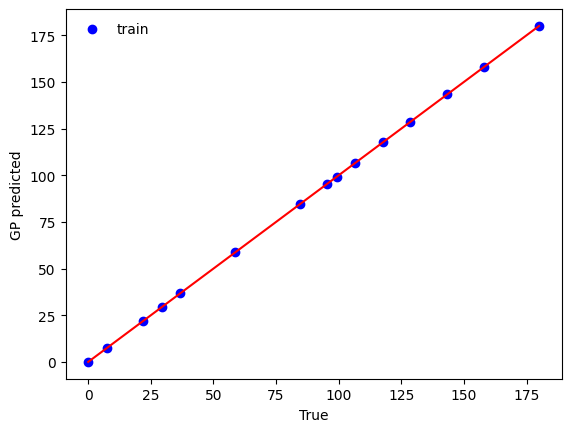

In [11]:
f_train = my_gpo.posterior_mean(X_train)["m(x)"]

my_line = np.linspace(np.min(y_train),np.max(y_train),10)

print('RMSE:', my_gpo.rmse(X_train,y_train)) # *100/np.mean(y_train),'%')

plt.scatter(y_train,f_train,color="blue",label = 'train')
plt.plot(my_line,my_line,c="red")
plt.xlabel("True")
plt.ylabel("GP predicted")
plt.legend(frameon = False)
plt.show()

RMSE: 1.165496934873466


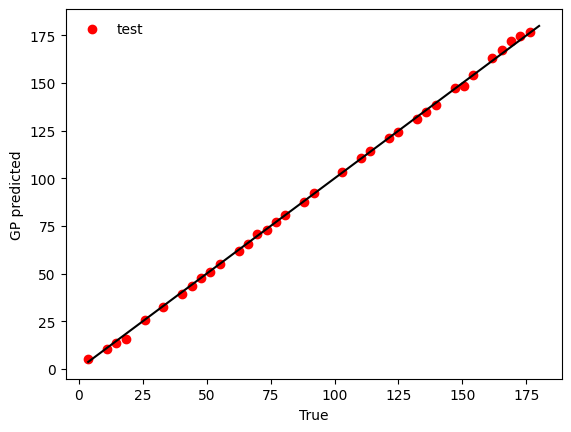

In [12]:
f = my_gpo.posterior_mean(X_test)["m(x)"]
posterior_var = my_gpo.posterior_covariance(X_test, variance_only=True, add_noise=False) # it does not matter if we added noise because it is 1e-6
var = posterior_var["v(x)"].flatten()

print('RMSE:', my_gpo.rmse(X_test,y_test)) # *100/np.mean(y_train),'%')


my_line = np.linspace(np.min(y_test),np.max(y_train),10)

plt.scatter(y_test,f,color="red",label = 'test')
#plt.scatter(y_train,f_train,color="blue",label = 'train')
plt.plot(my_line,my_line,c="black")
plt.xlabel("True")
plt.ylabel("GP predicted")
plt.legend(frameon = False)
plt.show()

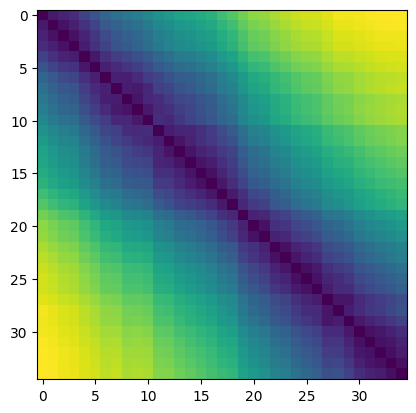

In [13]:
plt.imshow(distance_full[np.ix_(X_test.flatten(), X_test.flatten())])

# Running Multiple trials with different test-train split

In [16]:
import json
import numpy as np
from sklearn.model_selection import train_test_split

all_distance_metrics = ['sliced_Wass'] # 'JS' ,
all_splitting_ratios = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

# Define hyperparameter bounds
bounds = np.empty((3, 2))
bounds[0] = np.array([1e-2, 100000])     # sigma_f: signal variance      
bounds[1] = np.array([1e-3, 2])       # length_scale
bounds[2] = np.array([0, 360])         #  mean

init_hps = np.mean(bounds, axis=1)

#angles = np.load('angles.npy')

# Dictionary to store all results
results = {}

for DISTANCE_METRIC in all_distance_metrics:
    print("="*70)
    print(f"Loading precomputed data and distances for {DISTANCE_METRIC}")
    print("="*70)
    
    distance_full = np.load(f'volumes_distance_{DISTANCE_METRIC}.npy')
    
    results[DISTANCE_METRIC] = {}
    
    for splitting_ratio in all_splitting_ratios:
        print("\n" + "="*70)
        print(f"Splitting into train/test with test size = {splitting_ratio}")
        print("="*70)
        
        results[DISTANCE_METRIC][str(splitting_ratio)] = []
    
        for split_trial in range(30):
            print("Splitting trial", split_trial+1)
            
            indices = np.arange(len(angles))
            train_idx_unsorted, test_idx_unsorted = train_test_split(
                indices, 
                test_size=splitting_ratio, 
                random_state=split_trial + int(splitting_ratio * 1000)
            )
            
            train_idx = np.sort(train_idx_unsorted)
            test_idx = np.sort(test_idx_unsorted)
            
            # Filter test indices to only keep those within train range
            min_train = np.min(train_idx)
            max_train = np.max(train_idx)

            # Keep only test indices within [min_train, max_train]
            mask = (test_idx >= min_train) & (test_idx <= max_train)
            test_idx_filtered = test_idx[mask]

            # Extract train and test angles using filtered indices
            y_train = angles[train_idx]
            y_test = angles[test_idx_filtered]   

            # Use the sorted indices as "features" for GP
            X_train = train_idx.reshape(-1, 1)                  # Shape: (n_train, 1)
            X_test = test_idx_filtered.reshape(-1, 1)           # Shape: (n_test_filtered, 1)
            
            
            # ===== Define functions with proper closure over train_idx and distance_full =====
            
            def my_kernel(x1, x2, hps, _distance_full=distance_full):
                """
                x1, x2: arrays of indices (either train_idx or test_idx)
                """
                x1_idx = x1.astype(int).flatten()
                x2_idx = x2.astype(int).flatten()
                
                # Use the captured _distance_full
                my_distance = _distance_full[np.ix_(x1_idx, x2_idx)]
                
                k = hps[0] * kernels.matern_kernel_diff1(my_distance, hps[1])
                
                return k

            def my_noise(x, hps):
                s = np.ones(len(x)) * 1e-2
                return np.diag(s)

            def my_mean(x, hps):  # If hps[2] could change, capture it too
                m = np.ones(len(x)) * hps[2]
                return m

            # ===== Now train the GP =====
            
            my_gpo = GPOptimizer(X_train, y_train,
                                init_hyperparameters=init_hps,
                                kernel_function=my_kernel,
                                prior_mean_function=my_mean, 
                                noise_function=my_noise)
            
            my_gpo.train(hyperparameter_bounds=bounds, 
                        init_hyperparameters=init_hps, 
                        method='global')
            
            print(my_gpo.get_hyperparameters())
            
            rmse_value = my_gpo.rmse(X_test, y_test)
            print('RMSE:', rmse_value)
            
            results[DISTANCE_METRIC][str(splitting_ratio)].append({
                'trial': split_trial,
                'rmse': float(rmse_value),
                'train_size': len(train_idx),
                'test_size': len(test_idx),
                'train_ratio': 1 - splitting_ratio
            })

# Save results to JSON
with open('Matern_kernel_RMSEs.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\n" + "="*70)
print("Results saved to Matern_kernel_RMSEs.json")
print("="*70)

Loading precomputed data and distances for sliced_Wass

Splitting into train/test with test size = 0.2
Splitting trial 1
[511.16378239   1.9999825   88.54665038]
RMSE: 0.5569103622712636
Splitting trial 2
[518.71183364   1.99999495  89.35069557]
RMSE: 0.7957337257159796
Splitting trial 3
[487.17992888   1.99999439  91.55410702]
RMSE: 1.010101575287214
Splitting trial 4
[522.20069613   1.99996794  89.65417625]
RMSE: 0.776718108411913
Splitting trial 5
[515.68956279   1.99999268  88.96324801]
RMSE: 1.0153933668855175
Splitting trial 6
[502.81340447   1.99999977  92.02748165]
RMSE: 0.5286893679807033
Splitting trial 7
[500.52008982   1.99999913  88.90465735]
RMSE: 1.2555113338057997
Splitting trial 8
[471.01732293   1.99997903  84.19242832]
RMSE: 0.4248942912992065
Splitting trial 9
[515.0772782    1.99998603  89.43748369]
RMSE: 0.745770826700404
Splitting trial 10
[497.10069579   1.99998411  91.65769852]
RMSE: 0.8252851297398924
Splitting trial 11
[503.2658005    1.99999878  92.99640397]

Loaded results from New_kernel.json


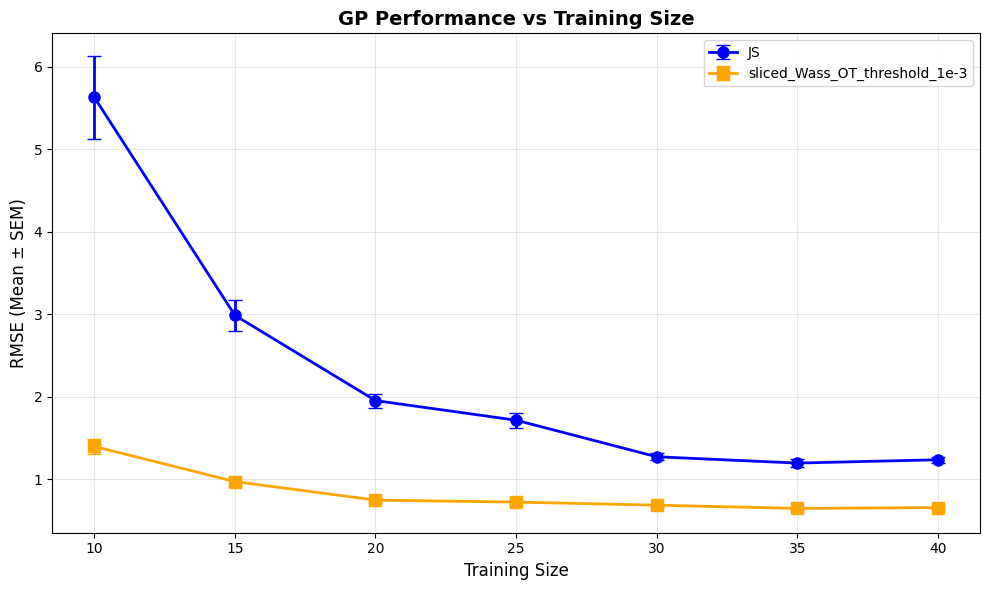

Plot saved to New_kernel_performance.png


In [ ]:
bounds = np.empty((3, 2))
bounds[0] = np.array([1e-2, 100000])     # sigma_f: signal variance      
bounds[1] = np.array([1e-3, 2])       # length_scale
bounds[2] = np.array([0, 360])         #  mean


import json
import numpy as np
import matplotlib.pyplot as plt

# ==================== LOAD RESULTS ====================

with open('Matern_kernel_RMSEs.json', 'r') as f:
    results = json.load(f)

print("Loaded results from New_kernel.json")

# ==================== PLOTTING ====================

all_distance_metrics = ['JS' ,'sliced_Wass_OT_threshold_1e-3','sliced_Wass_OT_threshold_1e-5','sliced_Wass_OT_threshold_0.5']

# Compute statistics for plotting
plot_data = {}

for metric in all_distance_metrics:
    plot_data[metric] = {
        'train_sizes': [],
        'train_ratios': [],
        'mean_rmse': [],
        'sem_rmse': []
    }
    
    for splitting_ratio_key in sorted(results[metric].keys(), key=float):
        trials = results[metric][splitting_ratio_key]
        rmse_values = [t['rmse'] for t in trials]
        
        plot_data[metric]['train_sizes'].append(trials[0]['train_size'])
        plot_data[metric]['train_ratios'].append(trials[0]['train_ratio'])
        plot_data[metric]['mean_rmse'].append(np.mean(rmse_values))
        plot_data[metric]['sem_rmse'].append(np.std(rmse_values) / np.sqrt(len(rmse_values)))

# Create figure
plt.figure(figsize=(10, 6))

colors = {'JS': 'blue', 'sliced_Wass_OT_threshold_1e-3': 'orange'}
markers = {'JS': 'o', 'sliced_Wass_OT_threshold_1e-3': 's'}

for metric in all_distance_metrics:
    data = plot_data[metric]
    
    plt.errorbar(data['train_sizes'], 
                 data['mean_rmse'], 
                 yerr=data['sem_rmse'],
                 label=metric,
                 marker=markers[metric],
                 color=colors[metric],
                 capsize=5,
                 linewidth=2,
                 markersize=8)

plt.xlabel('Training Size', fontsize=12)
plt.ylabel('RMSE (Mean ± SEM)', fontsize=12)
plt.title('GP Performance vs Training Size', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('New_kernel_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved to New_kernel_performance.png")